In [2]:
# Install libraries - Updated to a version confirmed in your error message
!pip install mediapipe==0.10.33 tensorflow opencv-python scikit-learn kaggle -q

import os
import random
import shutil
import cv2
import mediapipe as mp
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from google.colab import files

# 1. Upload kaggle.json
if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("Please upload your kaggle.json file:")
    uploaded = files.upload()
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

# 2. Download and Unzip (Added -o to overwrite and -q for quiet)
!kaggle datasets download -d grassknoted/asl-alphabet -p dataset/
!unzip -oq dataset/asl-alphabet.zip -d dataset/

# 3. --- FIXING THE PATHS ---
# Based on how this dataset unzips, the images are usually here:
SRC = "dataset/asl_alphabet_train/asl_alphabet_train"

# Fallback check: if the extra folder layer isn't there, use the parent
if not os.path.exists(SRC):
    SRC = "dataset/asl_alphabet_train"

DST = "dataset_small"

if os.path.exists(DST):
    shutil.rmtree(DST)
os.makedirs(DST, exist_ok=True)

# 4. Get first 10 classes
all_folders = [d for d in os.listdir(SRC) if os.path.isdir(os.path.join(SRC, d))]
classes = sorted(all_folders)[:10]

print(f"Sampling from: {SRC}")
print(f"Classes found: {classes}")

for cls in classes:
    src_path = os.path.join(SRC, cls)
    os.makedirs(os.path.join(DST, cls), exist_ok=True)

    imgs = [f for f in os.listdir(src_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

    # Take 100 images per class
    sampled = random.sample(imgs, min(100, len(imgs)))
    for img in sampled:
        shutil.copy(os.path.join(src_path, img), os.path.join(DST, cls, img))

print(f"Data is now ready! Sampled {len(classes)} classes into {DST}")

Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
asl-alphabet.zip: Skipping, found more recently modified local copy (use --force to force download)
Sampling from: dataset/asl_alphabet_train/asl_alphabet_train
Classes found: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
Data is now ready! Sampled 10 classes into dataset_small


In [3]:
import os
import sys

# 1. Nuke and Reinstall with specific compatible dependencies
!pip uninstall -y mediapipe protobuf
!pip install mediapipe==0.10.14 protobuf==4.25.3 --no-cache-dir -q

# 2. Force Python to re-scan the installed packages
import site
from importlib import reload
reload(site)

import mediapipe as mp
import cv2
import numpy as np

# 3. Manual check of the solutions folder
try:
    from mediapipe.python.solutions import hands as mp_hands
    hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.1)
    print("MediaPipe Solutions are active.")
except Exception as e:
    print(f"error!: {e}")
    # If this fails, we check the actual folder on the hard drive
    import mediapipe
    print(f"MediaPipe location: {mediapipe.__file__}")

# --- IF SUCCESSFUL, RUN EXTRACTION ---
DST = "dataset_small"
X, y = [], []

if os.path.exists(DST):
    print("Processing images...")
    for label in sorted(os.listdir(DST)):
        label_path = os.path.join(DST, label)
        if not os.path.isdir(label_path): continue
        for img_name in os.listdir(label_path):
            img = cv2.imread(os.path.join(label_path, img_name))
            if img is None: continue
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            result = hands.process(img_rgb)
            if result.multi_hand_landmarks:
                landmarks = [val for lm in result.multi_hand_landmarks[0].landmark for val in [lm.x, lm.y, lm.z]]
                X.append(landmarks)
                y.append(label)

    print(f"Extracted the samples.")
else:
    print("dataset_small not found. Please run the data sampling block.")

Found existing installation: mediapipe 0.10.14
Uninstalling mediapipe-0.10.14:
  Successfully uninstalled mediapipe-0.10.14
Found existing installation: protobuf 4.25.3
Uninstalling protobuf-4.25.3:
  Successfully uninstalled protobuf-4.25.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 72.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-api-core 2.30.0 requires protobuf<7.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.3 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.3 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.3 which is incompatible.
grpcio-status 1.7

In [6]:
import os
import sys

# force python to refresh its path
import site
from importlib import reload
reload(site)

try:
    import mediapipe as mp
    # manually trigger the solutions sub-module loading
    import mediapipe.python.solutions.hands as mp_hands
    print("mediapipe loaded.")
except Exception as e:
    print(f"error loading mediapipe: {e}")
    # last resort: manual path injection
    import glob
    mp_path = glob.glob('/usr/local/lib/python*/dist-packages/mediapipe')[0]
    sys.path.append(mp_path)
    import mediapipe as mp
    import mediapipe.python.solutions.hands as mp_hands

import cv2
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder

# use the direct reference we just imported
hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.1
)

dst = "dataset_small"
x_data = []
y_labels = []

if not os.path.exists(dst):
    print("error: dataset_small folder not found.")
else:
    print("processing images...")
    for label in sorted(os.listdir(dst)):
        label_path = os.path.join(dst, label)
        if not os.path.isdir(label_path): continue

        for img_name in os.listdir(label_path):
            img = cv2.imread(os.path.join(label_path, img_name))
            if img is None: continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            result = hands.process(img_rgb)

            if result.multi_hand_landmarks:
                landmarks = []
                for lm in result.multi_hand_landmarks[0].landmark:
                    landmarks.extend([lm.x, lm.y, lm.z])
                x_data.append(landmarks)
                y_labels.append(label)

    if len(x_data) > 0:
        x_final = np.array(x_data)
        le = LabelEncoder()
        y_encoded = le.fit_transform(y_labels)

        print(f"captured {len(x_final)} samples. training...")

        model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(63,)),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(len(np.unique(y_encoded)), activation='softmax')
        ])

        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        model.fit(x_final, y_encoded, epochs=15, batch_size=16, verbose=1)

        os.makedirs("models", exist_ok=True)
        model.save("models/sign_model.keras")
        print("model saved.")
    else:
        print("error: no hands detected.")

mediapipe loaded.
processing images...
captured 838 samples. training...
Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2625 - loss: 2.2217
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4368 - loss: 1.9764
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5967 - loss: 1.6483
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7697 - loss: 1.2923
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8305 - loss: 0.9854
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9069 - loss: 0.7472
Epoch 7/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9320 - loss: 0.5947
Epoch 8/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9272 - loss: 0.4945
Epoch 9/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9403 - loss: 0.4123
Epoch 10/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9678 - loss: 0.3357
Epoch 11/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9690 - loss: 0.2971
E

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


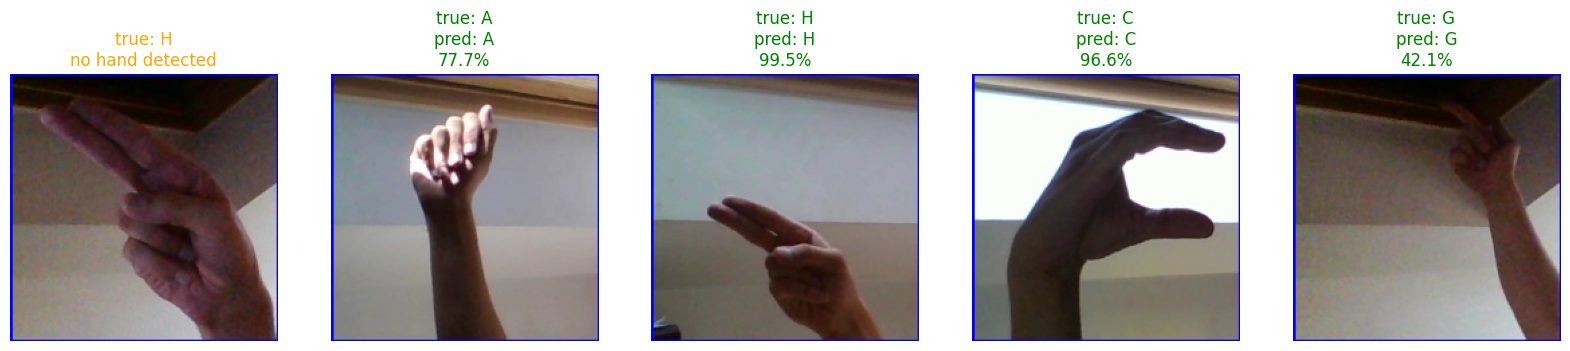

done. images saved to test_results.png. check your sidebar.


In [8]:
import os
import sys
import glob

# force-fix mediapipe path before anything else
try:
    import mediapipe as mp
    import mediapipe.python.solutions.hands as mp_hands
except (AttributeError, ImportError):
    # find where pip actually put it
    possible_paths = glob.glob('/usr/local/lib/python*/dist-packages')
    for p in possible_paths:
        if p not in sys.path:
            sys.path.append(p)
    import mediapipe as mp
    import mediapipe.python.solutions.hands as mp_hands

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random

# 1. load model
model_path = "models/sign_model.keras"
if not os.path.exists(model_path):
    print(f"error: {model_path} not found. train the model first.")
else:
    model = tf.keras.models.load_model(model_path)

    # 2. setup hands
    hands = mp_hands.Hands(
        static_image_mode=True,
        max_num_hands=1,
        min_detection_confidence=0.1
    )

    # 3. data paths
    test_src = "dataset/asl_alphabet_train/asl_alphabet_train"
    if not os.path.exists(test_src):
        test_src = "dataset/asl_alphabet_train"

    class_names = sorted([d for d in os.listdir(test_src) if os.path.isdir(os.path.join(test_src, d))])[:10]

    # 4. pick and predict
    plt.figure(figsize=(20, 10))
    count = 0

    while count < 5:
        random_class = random.choice(class_names)
        class_dir = os.path.join(test_src, random_class)
        img_name = random.choice(os.listdir(class_dir))
        img_path = os.path.join(class_dir, img_name)

        img = cv2.imread(img_path)
        if img is None: continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        result = hands.process(img_rgb)

        plt.subplot(1, 5, count + 1)
        plt.imshow(img_rgb)

        if result.multi_hand_landmarks:
            lm_list = []
            for lm in result.multi_hand_landmarks[0].landmark:
                lm_list.extend([lm.x, lm.y, lm.z])

            prediction = model.predict(np.array([lm_list]), verbose=0)
            pred_idx = np.argmax(prediction)
            conf = np.max(prediction) * 100

            label_text = f"true: {random_class}\npred: {class_names[pred_idx]}\n{conf:.1f}%"
            plt.title(label_text, fontsize=12, color='green' if random_class == class_names[pred_idx] else 'red')
        else:
            plt.title(f"true: {random_class}\nno hand detected", fontsize=12, color='orange')

        plt.axis('off')
        count += 1

    # 5. save the actual image to your sidebar
    output_path = "test_results.png"
    plt.savefig(output_path)
    plt.show()
    print(f"done. images saved to {output_path}. check your sidebar.")